In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "numpy<2", "xgboost==2.1.1", "matplotlib>=3.7",
    "scipy>=1.10", "scikit-learn>=1.3", "pandas>=2.0",
    "--quiet"], check=True)
print("Deps OK — RESTART KERNEL, then run from Cell 2")

Deps OK — RESTART KERNEL, then run from Cell 2


In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from sklearn.model_selection import LeaveOneGroupOut
from xgboost import XGBClassifier
import xgboost as xgb_lib

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
print(f"XGBoost : {xgb_lib.__version__}")

XGBoost : 2.1.1


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR      = "../data/pads_preprocessed"
MOVEMENT_DIR  = os.path.join(BASE_DIR, "movement")
FILE_LIST_CSV = os.path.join(BASE_DIR, "file_list.csv")

assert os.path.isdir(MOVEMENT_DIR),   f"Not found: {MOVEMENT_DIR}"
assert os.path.isfile(FILE_LIST_CSV), f"Not found: {FILE_LIST_CSV}"

# ── PADS raw layout ────────────────────────────────────────────────────────
FS          = 100
N_CHANNELS  = 132       # 11 tasks × 2 wrists × 2 sensors × 3 axes
N_SAMPLES   = 488

ALL_TASKS   = ["Relaxed1","Relaxed2","RelaxedTask1","RelaxedTask2",
               "StretchHold","HoldWeight","DrinkGlas","CrossArms",
               "TouchNose","Entrainment1","Entrainment2"]
ALL_WRISTS  = ["LeftWrist","RightWrist"]
SENSORS     = ["Accelerometer","Gyroscope"]
AXES        = ["X","Y","Z"]

ALL_CHANNEL_NAMES = [
    f"{task}_{wrist}_{sensor}_{axis}"
    for task   in ALL_TASKS
    for wrist  in ALL_WRISTS
    for sensor in SENSORS
    for axis   in AXES
]
assert len(ALL_CHANNEL_NAMES) == N_CHANNELS, "Channel count mismatch"

# ── Single-wrist subset ────────────────────────────────────────────────────
KEEP_WRIST  = "RightWrist"
KEEP_TASKS  = ["TouchNose","Entrainment1","Entrainment2","CrossArms",
               "DrinkGlas","HoldWeight","StretchHold","RelaxedTask1","RelaxedTask2"]

CHANNEL_NAMES_SINGLE = [
    f"{task}_{KEEP_WRIST}_{sensor}_{axis}"
    for task   in KEEP_TASKS
    for sensor in SENSORS
    for axis   in AXES
]
# 9 tasks × 1 wrist × 2 sensors × 3 axes = 54 channels

FEAT_NAMES_PER_CH = ["mean","std","rms","peak_amp","kurtosis","skewness",
                     "tremor_power_ratio","dom_freq","spectral_entropy",
                     "mean_freq","zcr","energy"]
N_FEATS = len(FEAT_NAMES_PER_CH)   # 12

# 54 × 12 + 3 metadata = 651
N_FEATURES_SINGLE = len(CHANNEL_NAMES_SINGLE) * N_FEATS + 3

BEST_THRESHOLD = 0.84   # inherited from NB04 ROC analysis

print(f"Single-wrist channels : {len(CHANNEL_NAMES_SINGLE)}")
print(f"Feature vector length : {N_FEATURES_SINGLE}")

Single-wrist channels : 54
Feature vector length : 651


In [3]:
def extract_features_from_signal(signal, fs=FS):
    feats = []
    feats.append(np.mean(signal))
    feats.append(np.std(signal))
    feats.append(np.sqrt(np.mean(signal**2)))
    feats.append(np.max(np.abs(signal)))
    feats.append(float(kurtosis(signal, fisher=True)))
    feats.append(float(skew(signal)))

    n     = len(signal)
    freqs = rfftfreq(n, d=1.0/fs)
    fft_mag = np.abs(rfft(signal)) / n
    total_power = np.sum(fft_mag**2) + 1e-12

    tremor_mask = (freqs >= 4) & (freqs <= 6)
    feats.append(np.sum(fft_mag[tremor_mask]**2) / total_power)
    feats.append(float(freqs[np.argmax(fft_mag)]))

    psd_norm = fft_mag**2 / total_power
    psd_norm = psd_norm[psd_norm > 0]
    feats.append(float(-np.sum(psd_norm * np.log(psd_norm))))
    feats.append(float(np.sum(freqs * fft_mag**2) / total_power))
    feats.append(float(np.sum(np.diff(np.sign(signal)) != 0) / n))
    feats.append(float(np.sum(signal**2)))
    return np.array(feats, dtype=np.float32)


def load_subject_raw_features(subject_id):
    """Returns full 132-channel × 12-feat flat vector, or None."""
    sid   = str(subject_id).zfill(3)
    fpath = os.path.join(MOVEMENT_DIR, f"{sid}_ml.bin")
    if not os.path.isfile(fpath):
        return None
    raw = np.fromfile(fpath, dtype=np.float64)
    if raw.size != N_CHANNELS * N_SAMPLES:
        return None
    data = raw.reshape(N_CHANNELS, N_SAMPLES)
    feats = np.concatenate([extract_features_from_signal(data[ch])
                            for ch in range(N_CHANNELS)])
    return feats.astype(np.float32)


print("Feature extractor OK ✅")

Feature extractor OK ✅


In [4]:
df_meta       = pd.read_csv(FILE_LIST_CSV)
df_meta       = df_meta[df_meta["label"].isin([0,1])].reset_index(drop=True)
le_gender     = LabelEncoder().fit(df_meta["gender"].fillna("unknown"))
le_handedness = LabelEncoder().fit(df_meta["handedness"].fillna("unknown"))

# ── Index mapping: which columns in raw 132-ch vector to keep ─────────────
keep_ch_idx = [i for i, ch in enumerate(ALL_CHANNEL_NAMES)
               if ch in set(CHANNEL_NAMES_SINGLE)]
keep_feat_idx = (
    [i * N_FEATS + f for i in keep_ch_idx for f in range(N_FEATS)]
    + list(range(N_CHANNELS * N_FEATS, N_CHANNELS * N_FEATS + 3))  # metadata
)

# ── Feature names (for inference service contract) ─────────────────────────
imu_feat_names = [
    f"{ALL_CHANNEL_NAMES[i]}__{feat}"
    for i in keep_ch_idx
    for feat in FEAT_NAMES_PER_CH
]
feature_names = imu_feat_names + ["age", "gender_enc", "handedness_enc"]
assert len(feature_names) == N_FEATURES_SINGLE, "Feature name count mismatch"

# ── Build X, y, groups ────────────────────────────────────────────────────
all_X, all_y, all_groups = [], [], []

for _, row in df_meta.iterrows():
    sid   = str(row["id"]).zfill(3)
    raw_f = load_subject_raw_features(sid)
    if raw_f is None:
        continue
    age   = float(row["age"])        if pd.notna(row["age"])        else -1.0
    g_enc = float(le_gender.transform(
                  [row["gender"]      if pd.notna(row["gender"])      else "unknown"])[0])
    h_enc = float(le_handedness.transform(
                  [row["handedness"]  if pd.notna(row["handedness"])  else "unknown"])[0])

    full_vec = np.concatenate([raw_f, [age, g_enc, h_enc]])
    all_X.append(full_vec[keep_feat_idx])
    all_y.append(int(row["label"]))
    all_groups.append(sid)

X_full  = np.vstack(all_X).astype(np.float32)
y       = np.array(all_y, dtype=np.int32)
groups  = np.array(all_groups, dtype=str)

assert X_full.shape[1] == N_FEATURES_SINGLE, \
    f"Shape mismatch: got {X_full.shape[1]}, expected {N_FEATURES_SINGLE}"

print(f"X shape        : {X_full.shape}")
print(f"Label balance  : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Subjects       : {len(groups)}")

X shape        : (355, 651)
Label balance  : {0: 79, 1: 276}
Subjects       : 355


In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
print("Scaled ✅")

Scaled ✅


In [6]:
logo         = LeaveOneGroupOut()
loso_results = []
spw_global   = (y == 0).sum() / (y == 1).sum()

for fold, (train_idx, test_idx) in enumerate(logo.split(X_scaled, y, groups)):
    spw = (y[train_idx] == 0).sum() / (y[train_idx] == 1).sum()
    clf = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=42,
        eval_metric="logloss", verbosity=0,
    )
    clf.fit(X_scaled[train_idx], y[train_idx])
    proba = clf.predict_proba(X_scaled[test_idx])[:, 1]
    loso_results.append({
        "subject"   : groups[test_idx][0],
        "true_label": int(y[test_idx][0]),
        "proba"     : float(proba[0]),
    })
    if (fold + 1) % 50 == 0:
        print(f"  Fold {fold+1}/{len(groups)} done")

res = pd.DataFrame(loso_results)
res["subject"] = res["subject"].astype(int).astype(str).str.zfill(3)
res["pred"]    = (res["proba"] >= BEST_THRESHOLD).astype(int)
res["correct"] = (res["pred"] == res["true_label"]).astype(int)

bal_acc = balanced_accuracy_score(res["true_label"], res["pred"])
print(f"\nSingle-wrist LOSO Balanced Accuracy : {bal_acc:.4f}")
print(classification_report(res["true_label"], res["pred"],
                             target_names=["Healthy","PD"]))

  Fold 50/355 done
  Fold 100/355 done
  Fold 150/355 done
  Fold 200/355 done
  Fold 250/355 done
  Fold 300/355 done
  Fold 350/355 done

Single-wrist LOSO Balanced Accuracy : 0.7276
              precision    recall  f1-score   support

     Healthy       0.42      0.76      0.54        79
          PD       0.91      0.70      0.79       276

    accuracy                           0.71       355
   macro avg       0.66      0.73      0.66       355
weighted avg       0.80      0.71      0.73       355



In [13]:
res = res.rename(columns={"proba": "prob_pd"})
res["pred"] = (res["prob_pd"] >= BEST_THRESHOLD).astype(int)

In [14]:
# ── Inspect NB04 CSV first ─────────────────────────────────────────────────
nb04_path = "../models/res_xgb_loso_04.csv"
assert os.path.isfile(nb04_path), f"Not found: {nb04_path}"

res_nb04 = pd.read_csv(nb04_path)
print("NB04 CSV columns:", list(res_nb04.columns))
print(res_nb04.head(3))

NB04 CSV columns: ['subject', 'true_label', 'predicted_label', 'prob_pd', 'correct']
   subject  true_label  predicted_label   prob_pd  correct
0        1           0                0  0.765019        1
1        3           0                0  0.670664        1
2        4           1                1  0.916816        1


In [15]:
# Load NB04 LOSO results for side-by-side comparison
nb04_path = "../models/res_xgb_loso_04.csv"
assert os.path.isfile(nb04_path), f"Not found: {nb04_path}"

res_nb04 = pd.read_csv(nb04_path)
res_nb04["subject"] = res_nb04["subject"].astype(int).astype(str).str.zfill(3)
res_nb04["pred"]    = (res_nb04["prob_pd"] >= BEST_THRESHOLD).astype(int)

bal_acc_nb04 = balanced_accuracy_score(res_nb04["true_label"], res_nb04["pred"])

print("── Balanced Accuracy Comparison ──────────────────")
print(f"  NB04  dual-wrist  : {bal_acc_nb04:.4f}")
print(f"  NB06  single-wrist: {bal_acc:.4f}")
print(f"  Delta             : {bal_acc - bal_acc_nb04:+.4f}")

── Balanced Accuracy Comparison ──────────────────
  NB04  dual-wrist  : 0.7520
  NB06  single-wrist: 0.7276
  Delta             : -0.0244


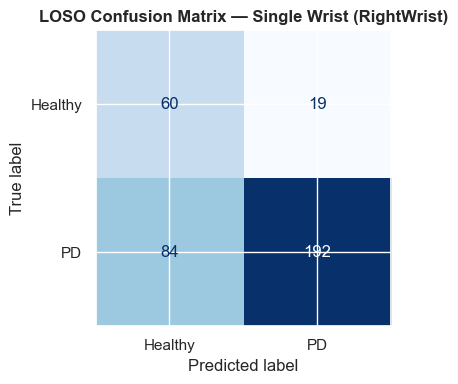

Saved → confusion_matrix_sw_06.png


In [16]:
cm = confusion_matrix(res["true_label"], res["pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Healthy","PD"])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("LOSO Confusion Matrix — Single Wrist (RightWrist)", fontweight="bold")
plt.tight_layout()
plt.savefig("../models/confusion_matrix_sw_06.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrix_sw_06.png")

In [22]:
print(res.columns.tolist())

['subject', 'true_label', 'prob_pd', 'pred', 'correct']


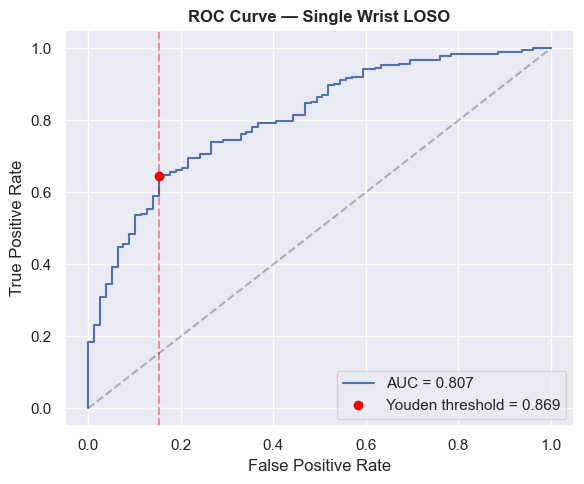

AUC                    : 0.8066
Youden best threshold  : 0.8688
NB04 inherited threshold: 0.84

→ Use 0.87 as BEST_THRESHOLD_SW in inference service


In [18]:
fpr, tpr, thresholds = roc_curve(res["true_label"], res["prob_pd"])
roc_auc = auc(fpr, tpr)

# Youden J = TPR - FPR → best operating point
j_scores   = tpr - fpr
best_idx   = np.argmax(j_scores)
best_thresh_youden = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax.scatter(fpr[best_idx], tpr[best_idx], color="red", zorder=5,
           label=f"Youden threshold = {best_thresh_youden:.3f}")
ax.axvline(x=fpr[best_idx], color="red", linestyle="--", alpha=0.4)
ax.plot([0,1],[0,1],"k--", alpha=0.3)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Single Wrist LOSO", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../models/roc_curve_sw_06.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"AUC                    : {roc_auc:.4f}")
print(f"Youden best threshold  : {best_thresh_youden:.4f}")
print(f"NB04 inherited threshold: {BEST_THRESHOLD}")
print(f"\n→ Use {best_thresh_youden:.2f} as BEST_THRESHOLD_SW in inference service")

In [19]:
spw_full = (y == 0).sum() / (y == 1).sum()

clf_final = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_full, random_state=42,
    eval_metric="logloss", verbosity=0,
)
clf_final.fit(X_scaled, y)
print("Final model trained on full dataset ✅")

Final model trained on full dataset ✅


In [20]:
os.makedirs("../models", exist_ok=True)

with open("../models/xgb_single_wrist_06.pkl", "wb") as f:
    pickle.dump(clf_final, f)

with open("../models/scaler_single_wrist_06.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../models/feat_names_single_wrist_06.pkl", "wb") as f:
    pickle.dump(feature_names, f)

# save LOSO results for reference
res.to_csv("../models/res_loso_sw_06.csv", index=False)

# save label encoders — needed in inference service for gender/handedness
with open("../models/le_gender_06.pkl", "wb") as f:
    pickle.dump(le_gender, f)

with open("../models/le_handedness_06.pkl", "wb") as f:
    pickle.dump(le_handedness, f)

print("Saved artifacts:")
print("  xgb_single_wrist_06.pkl")
print("  scaler_single_wrist_06.pkl")
print("  feat_names_single_wrist_06.pkl")
print("  le_gender_06.pkl")
print("  le_handedness_06.pkl")
print("  res_loso_sw_06.csv")

Saved artifacts:
  xgb_single_wrist_06.pkl
  scaler_single_wrist_06.pkl
  feat_names_single_wrist_06.pkl
  le_gender_06.pkl
  le_handedness_06.pkl
  res_loso_sw_06.csv


In [21]:
_model  = pickle.load(open("../models/xgb_single_wrist_06.pkl",  "rb"))
_scaler = pickle.load(open("../models/scaler_single_wrist_06.pkl","rb"))
_feats  = pickle.load(open("../models/feat_names_single_wrist_06.pkl","rb"))

assert len(_feats) == N_FEATURES_SINGLE, "Feature name count mismatch after reload"

# Quick smoke test: predict on first 5 subjects
_X5 = _scaler.transform(X_full[:5])
_p  = _model.predict_proba(_X5)[:, 1]
print("Smoke test probabilities:", np.round(_p, 3))
print(f"Feature vector contract  : {len(_feats)} features ✅")
print("All artifacts verified ✅")

Smoke test probabilities: [0.026 0.031 0.946 0.996 0.985]
Feature vector contract  : 651 features ✅
All artifacts verified ✅
